## Repeater

### Prerequisites

In [27]:
import uuid
import time
from datetime import datetime, date

import numpy as np
import scipy as sp
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from utils import (
    Repeater,
    Generator,
    Evaluator,
    device,
)

### MIMO 5x2

#### Data

In [ ]:
A = np.array([[0, 1, 0, 0, 0],
              [-1, -0.5, 0, 0, 0],
              [0, 0, 0, 1, 0],
              [0, 0, -1, -0.5, 0],
              [0, 0, 0, 0, -1]])

B = np.array([[1, 0, 0, 0, 0],
              [0, 1, 0, 0, 0],
              [0, 0, 1, 0, 0],
              [0, 0, 0, 1, 0],
              [0, 0, 0, 0, 1]])

C = np.array([[1, 0, 0, 0, 0],
              [0, 1, 0, 0, 0]])

D = np.zeros((2, 5))

sys = sp.signal.StateSpace(A, B, C, D)

input_size = np.array(D).shape[1]
output_size = np.array(D).shape[0]

signal_length = 60*24*30
sf = 8
t = np.arange(0, signal_length/sf, 1/sf)

params = {
    "period": len(t),
    "initial_value": 0,
    "setpoint_min": 0,
    "setpoint_max": 1e1,
    "setpoint_step": 1e-1,
    "duration_min": 5e1,
    "duration_max": 2e2,
}

In [ ]:
generator = Generator()

x = []
for i in range(input_size):
    x.append(generator.generate_prbs(**params))
x = np.transpose(x)

_, y, _ = sp.signal.lsim(sys, x, t)

batch_size = 2**5
lag = 2**3

train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

In [ ]:
columns = []
for i in range(input_size + output_size):
    columns.append("sensor_" + generator.generate_key())

input_columns = columns[:input_size]
output_columns = columns[input_size:]

data = np.concatenate((x, y), axis=1)
df = pd.DataFrame(data=data)
df.columns = columns
df.index = pd.to_datetime(pd.date_range(start=date.today(), periods=df.shape[0], freq="min").strftime("%Y-%m-%d %H:%M:%S.%f"))
df.index.name = "date_time"

df.to_csv("./datasets/mimo_5x2_dataset.csv")

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(method="pearson"), annot=True)

In [ ]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

#### Model

In [ ]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**5,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**5,
}

In [ ]:
repeater = Repeater(**config).to(device)
print(repeater)

#### Train

In [ ]:
%%time
repeater.fit(train_dataloader, val_dataloader)

In [ ]:
repeater.data_min = generator.y_scaler.data_min_.tolist()
repeater.data_max = generator.y_scaler.data_max_.tolist()

model_path = './models/repeater_5x2.pt'
# torch.save(repeater.state_dict(), model_path)
torch.jit.script(repeater).save(model_path)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [ ]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

# repeater = torch.jit.load(model_path)
# repeater.eval()

In [ ]:
# y_test_scaled = repeater.forward(generator.x_test)
y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

In [ ]:
plt.figure(figsize=(12, 2))
plt.plot(repeater.y_tick)

In [ ]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()

#### Evaluate

In [ ]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

In [ ]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

In [ ]:
while True:
    time.sleep(1)
    pass

### Zyfra

#### Data

In [121]:
df = pd.read_csv('./datasets/zyfra/zyfra_dataset.csv', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)
# df.index = pd.to_datetime(df.index)
df.index = pd.to_datetime(pd.date_range(start=df.index[0], periods=df.shape[0], freq="h").strftime("%Y-%m-%d %H:%M:%S.%f"))
df = df.resample("h").interpolate(method="linear", limit_direction="both", axis=0)
df.index.name = "date_time"
df.interpolate(method="linear", limit_direction="both", axis=0)
df.fillna(method='ffill', axis=0, inplace=True)
df = df.applymap(lambda x: -x if x < 0 else x)

print(df.shape)

/tmp/ipykernel_97691/2534856036.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('./datasets/zyfra/zyfra_dataset.csv', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)


(22716, 86)


/tmp/ipykernel_97691/2534856036.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)
/tmp/ipykernel_97691/2534856036.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: -x if x < 0 else x)


In [122]:
# Z-score
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3471 entries, 2016-01-29 19:00:00 to 2018-07-31 14:00:00
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         3471 non-null   float64
 1   final.output.concentrate_pb                         3471 non-null   float64
 2   final.output.concentrate_sol                        3471 non-null   float64
 3   final.output.concentrate_au                         3471 non-null   float64
 4   final.output.recovery                               3471 non-null   float64
 5   final.output.tail_ag                                3471 non-null   float64
 6   final.output.tail_pb                                3471 non-null   float64
 7   final.output.tail_sol                               3471 non-null   float64
 8   final.output.tail_au                      

In [124]:
df.head()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date_time,,,,,,,,,,,,,,,,,,,,,
2016-01-29 19:00:00,6.216028,10.491338,7.720797,42.600851,72.878517,11.702119,1.205711,8.275870,2.476420,85.938251,...,13.623560,499.432242,13.083908,499.298491,14.036949,499.790065,12.628562,500.206739,14.694700,499.911762
2016-01-29 20:00:00,7.439060,9.674481,7.721502,40.859356,65.944912,12.271132,1.405582,4.790456,2.804975,61.813362,...,12.992534,498.622660,13.047256,497.090905,13.966294,497.920660,11.949566,499.477679,14.050020,498.618889
2016-01-30 14:00:00,5.958196,11.547179,7.215985,41.843601,76.435094,11.097235,1.074875,17.229048,2.374459,172.439903,...,15.006878,499.804568,12.959546,499.588686,13.997204,500.910019,14.003609,500.775497,15.996370,498.981722
2016-02-03 21:00:00,6.124834,9.189736,2.234204,43.667700,64.086801,12.079331,2.262333,11.399560,3.065930,150.002714,...,17.014247,504.222281,15.994992,497.165656,17.890720,498.594870,15.966759,500.106441,17.944239,499.794634
2016-02-04 01:00:00,6.200552,7.895123,2.630558,45.194430,52.963336,11.447746,2.195933,13.481369,3.444854,117.267682,...,16.994768,502.415746,16.025870,504.411666,17.947490,501.406673,16.020308,500.577946,18.018740,500.058834


In [ ]:
# feed_rate (t/h)
# feed_size (um)
# feed_au (%)
# concentrate (%)
# air (Nm³/h)
# level (m)
# reagents (g/t)

columns = [
    # 'final.output.concentrate_ag',
    # 'final.output.concentrate_pb',
    # 'final.output.concentrate_sol',
    # 'final.output.concentrate_au',
    # 'final.output.recovery',
    # 'final.output.tail_ag',
    # 'final.output.tail_pb',
    # 'final.output.tail_sol',
    # 'final.output.tail_au',
    # 'primary_cleaner.input.sulfate',
    # 'primary_cleaner.input.depressant',
    # 'primary_cleaner.input.feed_size',
    # 'primary_cleaner.input.xanthate',
    # 'primary_cleaner.output.concentrate_ag',
    # 'primary_cleaner.output.concentrate_pb',
    # 'primary_cleaner.output.concentrate_sol',
    # 'primary_cleaner.output.concentrate_au',
    # 'primary_cleaner.output.tail_ag',
    # 'primary_cleaner.output.tail_pb',
    # 'primary_cleaner.output.tail_sol',
    # 'primary_cleaner.output.tail_au',
    # 'primary_cleaner.state.floatbank8_a_air',
    # 'primary_cleaner.state.floatbank8_a_level',
    # 'primary_cleaner.state.floatbank8_b_air',
    # 'primary_cleaner.state.floatbank8_b_level',
    # 'primary_cleaner.state.floatbank8_c_air',
    # 'primary_cleaner.state.floatbank8_c_level',
    # 'primary_cleaner.state.floatbank8_d_air',
    # 'primary_cleaner.state.floatbank8_d_level',
    # 'rougher.calculation.sulfate_to_au_concentrate',
    # 'rougher.calculation.floatbank10_sulfate_to_au_feed',
    # 'rougher.calculation.floatbank11_sulfate_to_au_feed',
    # 'rougher.calculation.au_pb_ratio',
    'rougher.input.feed_ag',
    'rougher.input.feed_pb',
    'rougher.input.feed_rate',
    'rougher.input.feed_size',
    'rougher.input.feed_sol',
    'rougher.input.feed_au',
    'rougher.input.floatbank10_sulfate',
    'rougher.input.floatbank10_xanthate',
    # 'rougher.input.floatbank11_sulfate',
    # 'rougher.input.floatbank11_xanthate',
    'rougher.output.concentrate_ag',
    'rougher.output.concentrate_pb',
    'rougher.output.concentrate_sol',
    'rougher.output.concentrate_au',
    # 'rougher.output.recovery',
    'rougher.output.tail_ag',
    'rougher.output.tail_pb',
    'rougher.output.tail_sol',
    'rougher.output.tail_au',
    'rougher.state.floatbank10_a_air',
    'rougher.state.floatbank10_a_level',
    'rougher.state.floatbank10_b_air',
    'rougher.state.floatbank10_b_level',
    # 'rougher.state.floatbank10_c_air',
    # 'rougher.state.floatbank10_c_level',
    # 'rougher.state.floatbank10_d_air',
    # 'rougher.state.floatbank10_d_level',
    'rougher.state.floatbank10_e_air',
    # 'rougher.state.floatbank10_e_level',
    # 'rougher.state.floatbank10_f_air',
    # 'rougher.state.floatbank10_f_level',
    # 'secondary_cleaner.output.tail_ag',
    # 'secondary_cleaner.output.tail_pb',
    # 'secondary_cleaner.output.tail_sol',
    # 'secondary_cleaner.output.tail_au',
    # 'secondary_cleaner.state.floatbank2_a_air',
    # 'secondary_cleaner.state.floatbank2_a_level',
    # 'secondary_cleaner.state.floatbank2_b_air',
    # 'secondary_cleaner.state.floatbank2_b_level',
    # 'secondary_cleaner.state.floatbank3_a_air',
    # 'secondary_cleaner.state.floatbank3_a_level',
    # 'secondary_cleaner.state.floatbank3_b_air',
    # 'secondary_cleaner.state.floatbank3_b_level',
    # 'secondary_cleaner.state.floatbank4_a_air',
    # 'secondary_cleaner.state.floatbank4_a_level',
    # 'secondary_cleaner.state.floatbank4_b_air',
    # 'secondary_cleaner.state.floatbank4_b_level',
    # 'secondary_cleaner.state.floatbank5_a_air',
    # 'secondary_cleaner.state.floatbank5_a_level',
    # 'secondary_cleaner.state.floatbank5_b_air',
    # 'secondary_cleaner.state.floatbank5_b_level',
    # 'secondary_cleaner.state.floatbank6_a_air',
    # 'secondary_cleaner.state.floatbank6_a_level'
 ]

input_columns = [
    # 'rougher.input.feed_ag',
    # 'rougher.input.feed_pb',
    'rougher.input.feed_rate',
    'rougher.input.feed_size',
    # 'rougher.input.feed_sol',
    'rougher.input.feed_au',
    'rougher.input.floatbank10_sulfate',
    'rougher.input.floatbank10_xanthate',
    # 'rougher.input.floatbank11_sulfate',
    # 'rougher.input.floatbank11_xanthate',
    'rougher.state.floatbank10_a_air',
    'rougher.state.floatbank10_a_level',
    # 'rougher.state.floatbank10_b_air',
    # 'rougher.state.floatbank10_b_level',
    # 'rougher.state.floatbank10_c_air',
    # 'rougher.state.floatbank10_c_level',
    # 'rougher.state.floatbank10_d_air',
    # 'rougher.state.floatbank10_d_level',
    # 'rougher.state.floatbank10_e_air',
    # 'rougher.state.floatbank10_e_level',
    # 'rougher.state.floatbank10_f_air',
    # 'rougher.state.floatbank10_f_level',
]

output_columns = [
    # 'rougher.output.concentrate_ag',
    # 'rougher.output.concentrate_pb',
    # 'rougher.output.concentrate_sol',
    'rougher.output.concentrate_au',
    # 'rougher.output.tail_ag',
    # 'rougher.output.tail_pb',
    # 'rougher.output.tail_sol',
    'rougher.output.tail_au',
]

threshold = 0.1
selector = VarianceThreshold(threshold=threshold)
df_selected = pd.DataFrame(selector.fit_transform(df[input_columns]), columns=df[input_columns].columns[selector.get_support()])
input_columns = list(df_selected.columns.values)

df = df[columns]
df[input_columns + output_columns].to_csv("./datasets/zyfra/zyfra_flotation.csv")

<Axes: >

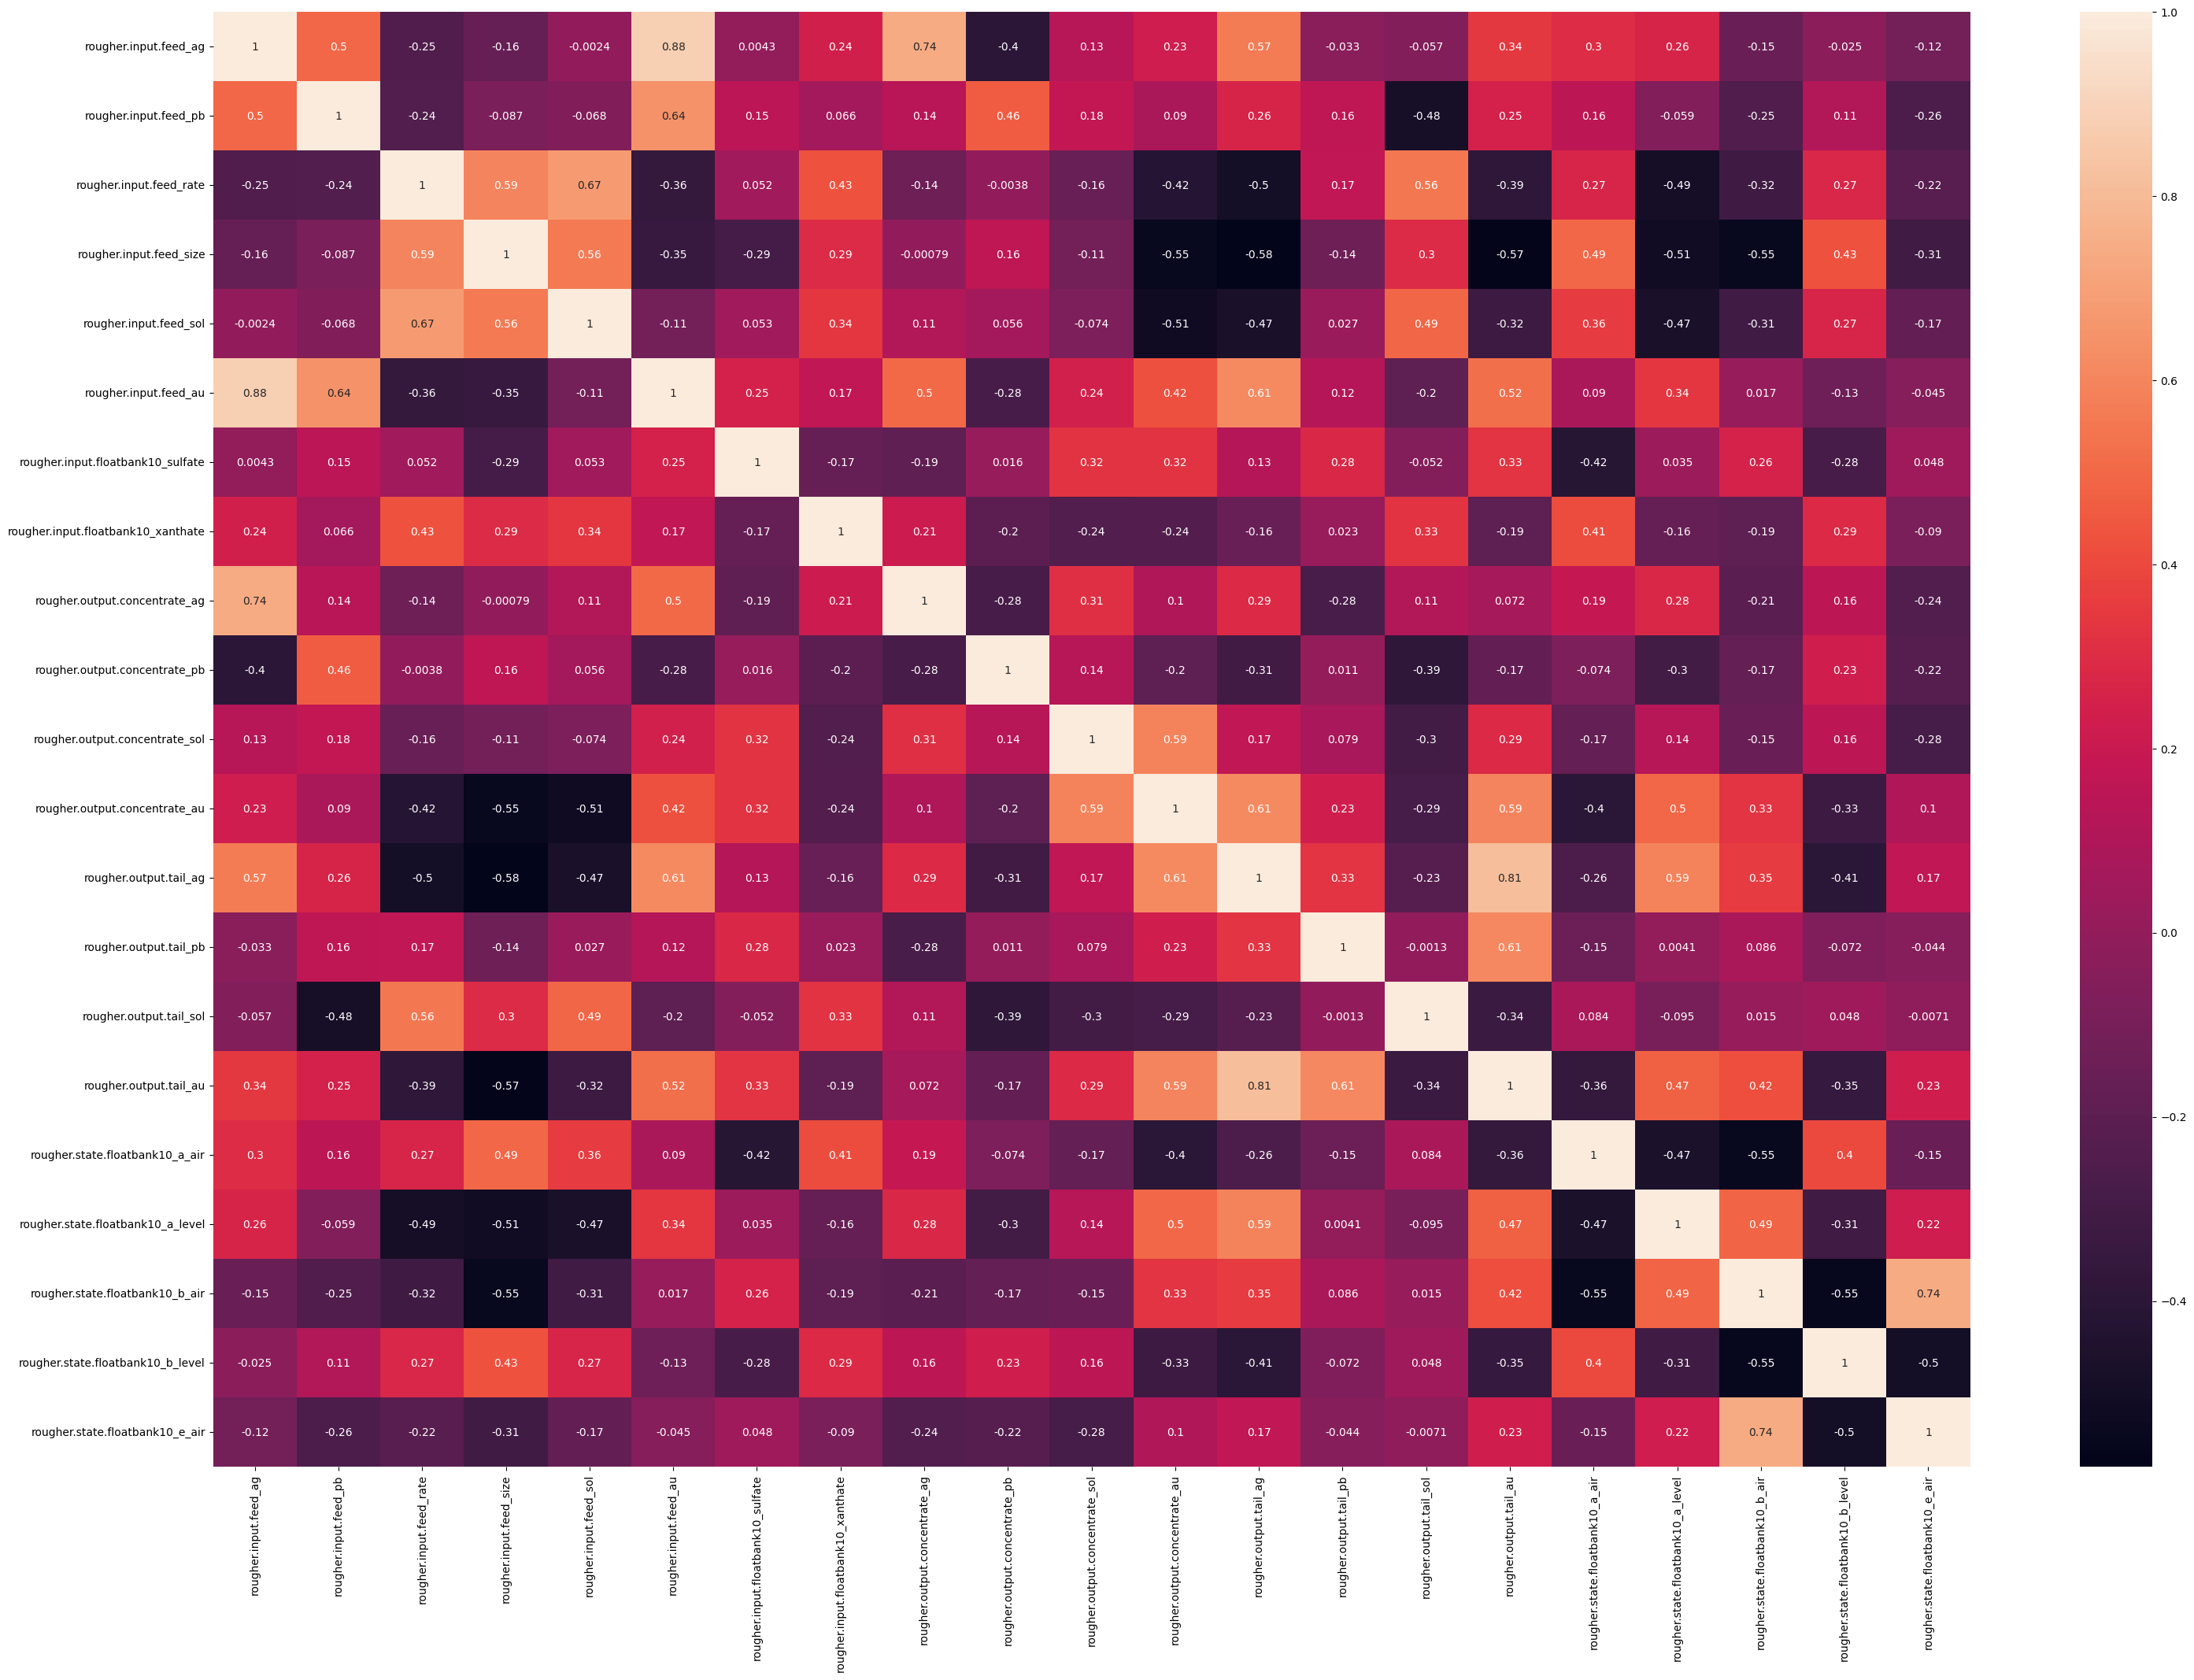

In [126]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(36, 24))
sns.heatmap(df_corr, annot=True)

In [127]:
# df_corr[output_columns][df_corr[output_columns].abs() >= 0.2]
df_corr[input_columns][df_corr[input_columns] >= 0.8]

,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level
rougher.input.feed_ag,NaN,NaN,0.876884,NaN,NaN,NaN,NaN
rougher.input.feed_pb,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_rate,1.0,NaN,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_size,NaN,1.0,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_sol,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rougher.input.feed_au,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
rougher.input.floatbank10_sulfate,NaN,NaN,NaN,1.0,NaN,NaN,NaN
rougher.input.floatbank10_xanthate,NaN,NaN,NaN,NaN,1.0,NaN,NaN
rougher.output.concentrate_ag,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rougher.output.concentrate_pb,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [129]:
df[input_columns + output_columns].describe()

,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.output.concentrate_au,rougher.output.tail_au
count,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000,3471.000000
mean,503.011965,57.810751,8.343269,12.239093,6.378400,1112.257590,358.871310,20.183798,1.682474
std,75.358772,13.317967,1.858852,2.907692,0.813650,165.964668,86.989593,2.175285,0.635347
min,175.365999,21.345670,3.168345,3.263654,3.260339,685.945050,293.920129,12.599414,0.200281
25%,450.561517,46.696826,6.865532,10.001154,5.992098,999.529965,299.949960,18.907332,1.208950
50%,510.242866,54.844849,8.258610,12.000040,6.402163,1001.266298,300.151319,20.293753,1.732911
75%,558.177783,67.925769,9.849150,14.732392,6.936372,1202.895579,499.525443,21.493483,2.115304
max,697.914084,90.420232,12.803823,20.005140,8.919601,1411.527154,504.408914,26.695481,3.477390


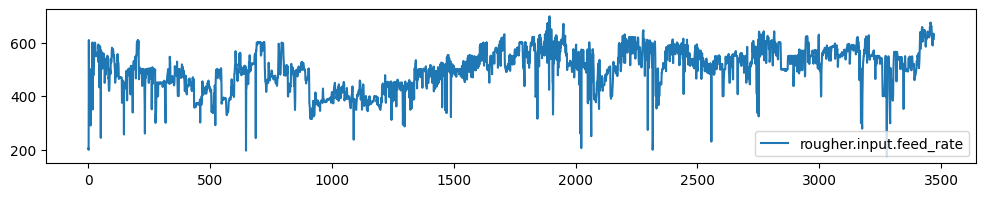

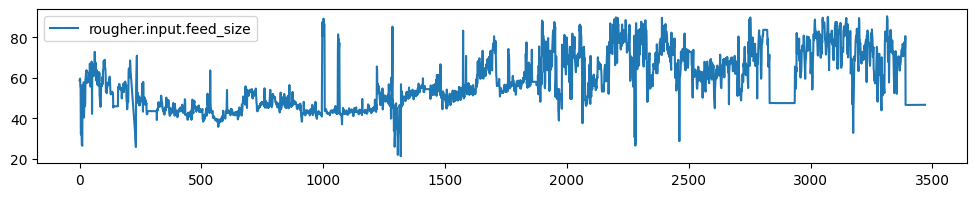

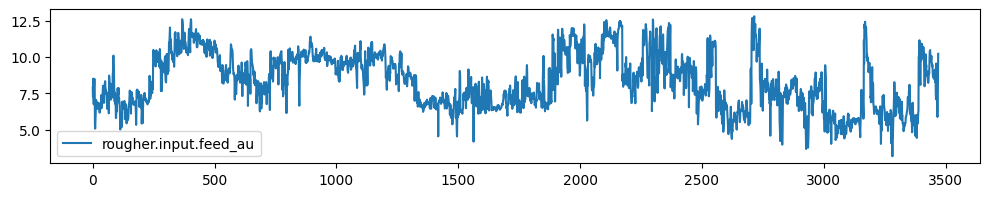

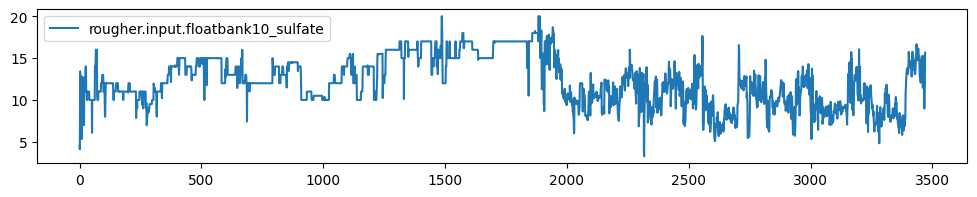

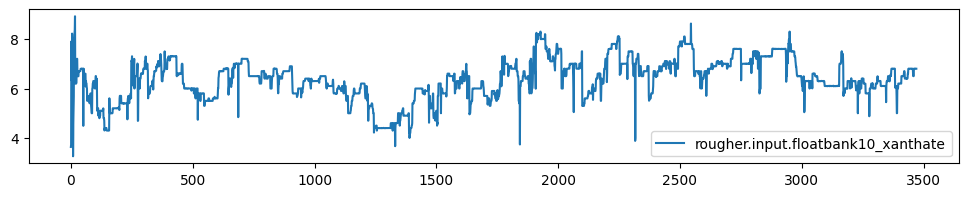

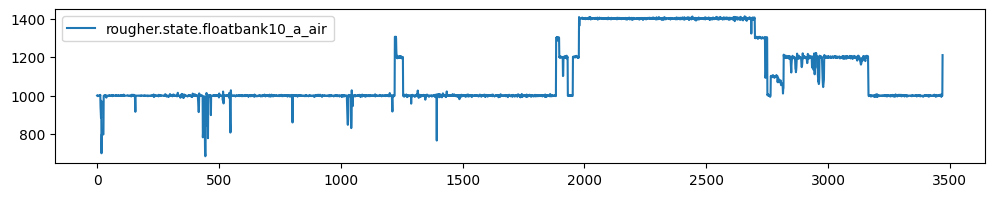

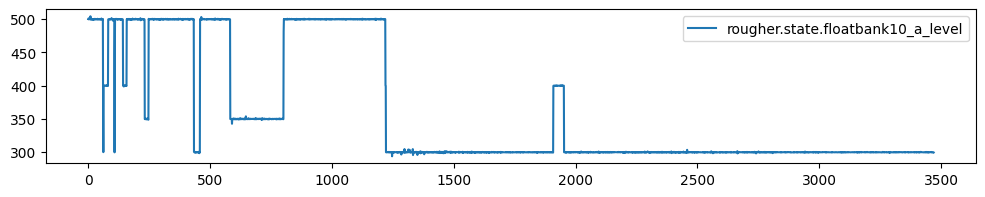

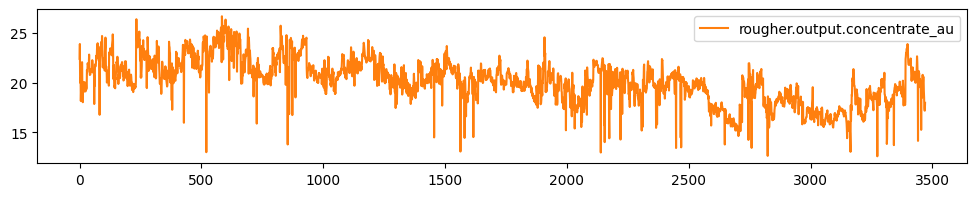

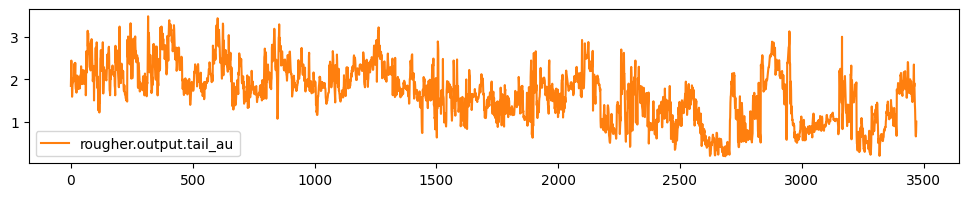

In [130]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [131]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [132]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**3,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**7
}

In [133]:
repeater = Repeater(**config).to(device)
print(repeater)

Repeater(
  (lstm): LSTM(9, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)


#### Train

In [134]:
%%time
repeater.fit(train_dataloader, val_dataloader)

Epoch 1/128
54/54 [====================================================================================================] 100%
0.0017s 0.0017s/step - train_loss: 0.06729376 - val_loss: 0.14992412 

Epoch 2/128
54/54 [====================================================================================================] 100%
0.0031s 0.0016s/step - train_loss: 0.06082277 - val_loss: 0.12055884 

Epoch 3/128
54/54 [====================================================================================================] 100%
0.0045s 0.0015s/step - train_loss: 0.05401965 - val_loss: 0.10976105 

Epoch 4/128
54/54 [====================================================================================================] 100%
0.0059s 0.0015s/step - train_loss: 0.04973600 - val_loss: 0.10141143 

Epoch 5/128
54/54 [====================================================================================================] 100%
0.0074s 0.0015s/step - train_loss: 0.04668982 - val_loss: 0.09578956 

Epoch 6/128
54/

In [135]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

model_path = "./models/{}.pt".format(uuid.uuid4())
torch.jit.script(repeater).save(model_path)

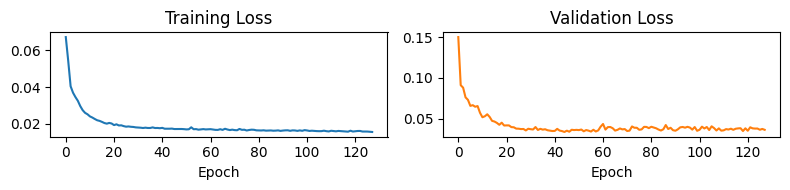

In [136]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [137]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

Repeater(
  (lstm): LSTM(9, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)

In [138]:
# y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test_scaled = repeater.test(generator.x_test)
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

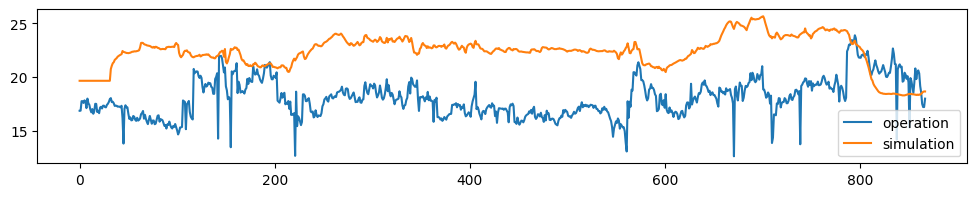

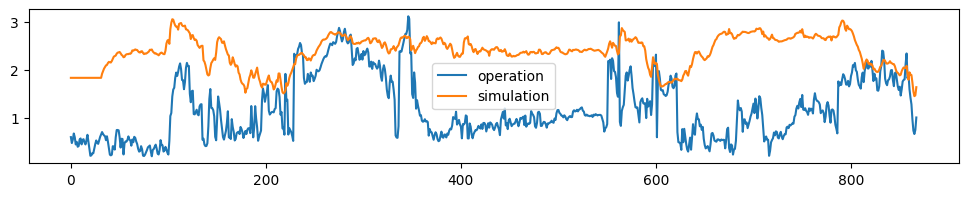

In [139]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()


#### Evaluate

In [140]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

{'explained_variance_score': -0.929398385567825, 'mean_absolute_error': 4.583704246180949, 'mean_squared_error': 24.86250171944695, 'root_mean_squared_error': np.float64(4.986231213997898), 'median_absolute_error': 5.079000274838732, 'mean_absolute_percentage_error': 0.26495967515463476, 'd2_absolute_error_score': -2.2858552325774344, 'd2_pinball_score': -2.2858552325774344, 'r2_score': -7.064231396882247}
{'explained_variance_score': -0.05018825810227745, 'mean_absolute_error': 1.1987342524239828, 'mean_squared_error': 1.841444591427177, 'root_mean_squared_error': np.float64(1.356998375617), 'median_absolute_error': 1.3593348446905418, 'mean_absolute_percentage_error': 1.7458621378664787, 'd2_absolute_error_score': -1.3195907478079287, 'd2_pinball_score': -1.3195907478079287, 'r2_score': -3.4487780881836363}


In [141]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

{'explained_variance_score': -0.48979332183504987,
 'mean_absolute_error': 2.8912192493024667,
 'mean_squared_error': 13.351973155437069,
 'root_mean_squared_error': np.float64(3.654035188040349),
 'median_absolute_error': 3.219167559764637,
 'mean_absolute_percentage_error': 1.0054109065105568,
 'd2_absolute_error_score': -1.8027229901926842,
 'd2_pinball_score': -1.8027229901926842,
 'r2_score': -5.25650474253294}

In [ ]:
while True:
    time.sleep(1)
    pass

### Iron Flotation

#### Data

In [ ]:
df = pd.read_csv('./datasets/iron/iron_flotation.csv', decimal=',', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)
df.index = pd.to_datetime(pd.date_range(start=df.index[0], periods=df.shape[0], freq="20s").strftime("%Y-%m-%d %H:%M:%S.%f"))
df = df.resample("20s").interpolate(method="linear", limit_direction="both", axis=0)
df.index.name = "date_time"
df.interpolate(method="linear", limit_direction="both", axis=0)
df.fillna(method='ffill', axis=0, inplace=True)

df = df.iloc[450000:500000, :]

/tmp/ipykernel_97691/2460477616.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('./datasets/iron/iron_flotation.csv', decimal=',', parse_dates=["date"], infer_datetime_format=True).set_index('date').astype(float)
/tmp/ipykernel_97691/2460477616.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)


In [ ]:
# Z-score
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23093 entries, 2017-06-22 05:50:20 to 2017-07-03 16:27:20
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   % Iron Feed                   23093 non-null  float64
 1   % Silica Feed                 23093 non-null  float64
 2   Starch Flow                   23093 non-null  float64
 3   Amina Flow                    23093 non-null  float64
 4   Ore Pulp Flow                 23093 non-null  float64
 5   Ore Pulp pH                   23093 non-null  float64
 6   Ore Pulp Density              23093 non-null  float64
 7   Flotation Column 01 Air Flow  23093 non-null  float64
 8   Flotation Column 02 Air Flow  23093 non-null  float64
 9   Flotation Column 03 Air Flow  23093 non-null  float64
 10  Flotation Column 04 Air Flow  23093 non-null  float64
 11  Flotation Column 05 Air Flow  23093 non-null  float64
 12  Flotation Column 06 Air F

In [ ]:
df.head()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date_time,,,,,,,,,,,,,,,,,,,,,
2017-06-22 05:50:20,50.7,22.76,2259.18,456.726973,394.662233,10.4718,1.709992,299.428,298.205,297.316,...,309.862,398.389,581.215000,537.685,582.833,432.628,394.554,399.006,66.13,1.28
2017-06-22 05:50:40,50.7,22.76,2407.68,451.154459,395.166977,10.4741,1.706240,297.366,298.123,298.516,...,307.495,394.468,581.138000,629.101,596.012,494.198,409.571,408.086,66.13,1.28
2017-06-22 05:51:00,50.7,22.76,2326.17,445.581946,395.671721,10.4763,1.702487,296.631,299.487,301.245,...,300.146,390.881,563.008000,680.913,615.234,497.355,407.163,409.404,66.13,1.28
2017-06-22 08:45:40,50.7,22.76,3111.29,523.561000,399.043000,10.0045,1.625310,297.049,293.576,300.359,...,307.546,395.732,515.609000,468.614,372.186,424.562,396.941,350.471,64.38,2.62
2017-06-22 08:46:40,50.7,22.76,2989.81,521.397000,399.174000,10.0016,1.624480,303.182,299.874,299.292,...,296.060,366.715,308.960667,388.066,419.438,389.706,412.393,394.780,64.38,2.62


In [ ]:
columns = [
    "% Iron Feed",
    "% Silica Feed",
    "Starch Flow",
    "Amina Flow",
    "Ore Pulp Flow",
    "Ore Pulp pH",
    "Ore Pulp Density",    
    "Flotation Column 01 Air Flow",
    "Flotation Column 02 Air Flow",
    "Flotation Column 03 Air Flow",
    "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow",
    "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level",
    "Flotation Column 02 Level",
    "Flotation Column 03 Level",
    "Flotation Column 04 Level",
    "Flotation Column 05 Level",
    "Flotation Column 06 Level",
    "Flotation Column 07 Level", 
    "% Iron Concentrate",
    "% Silica Concentrate",
]

input_columns = [
    "% Iron Feed",
    "% Silica Feed",
    "Starch Flow",
    "Amina Flow",
    "Ore Pulp Flow",
    "Ore Pulp pH",
    "Ore Pulp Density",    
    "Flotation Column 01 Air Flow",
    # "Flotation Column 02 Air Flow",
    # "Flotation Column 03 Air Flow",
    "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow",
    "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level",
    "Flotation Column 02 Level",
    # "Flotation Column 03 Level",
    "Flotation Column 04 Level",
    "Flotation Column 05 Level",
    "Flotation Column 06 Level",
    "Flotation Column 07 Level", 
]

input_columns = [
    "% Iron Feed",
    "% Silica Feed",
    "Starch Flow",
    "Amina Flow",
    "Ore Pulp Flow",
    "Ore Pulp pH",
    "Ore Pulp Density",    
    # "Flotation Column 01 Air Flow",
    # "Flotation Column 02 Air Flow",
    # "Flotation Column 03 Air Flow",
    # "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow",
    # "Flotation Column 06 Air Flow",
    # "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level",
    # "Flotation Column 02 Level",
    # "Flotation Column 03 Level",
    # "Flotation Column 04 Level",
    # "Flotation Column 05 Level",
    # "Flotation Column 06 Level",
    # "Flotation Column 07 Level", 
]

output_columns = [
    "% Iron Concentrate",
    "% Silica Concentrate",
]

# threshold = 0.1
# selector = VarianceThreshold(threshold=threshold)
# df_selected = pd.DataFrame(selector.fit_transform(df[input_columns]), columns=df[input_columns].columns[selector.get_support()])
# input_columns = list(df_selected.columns.values)


df.index.names = ["date_time"]
df = df[columns]

<Axes: >

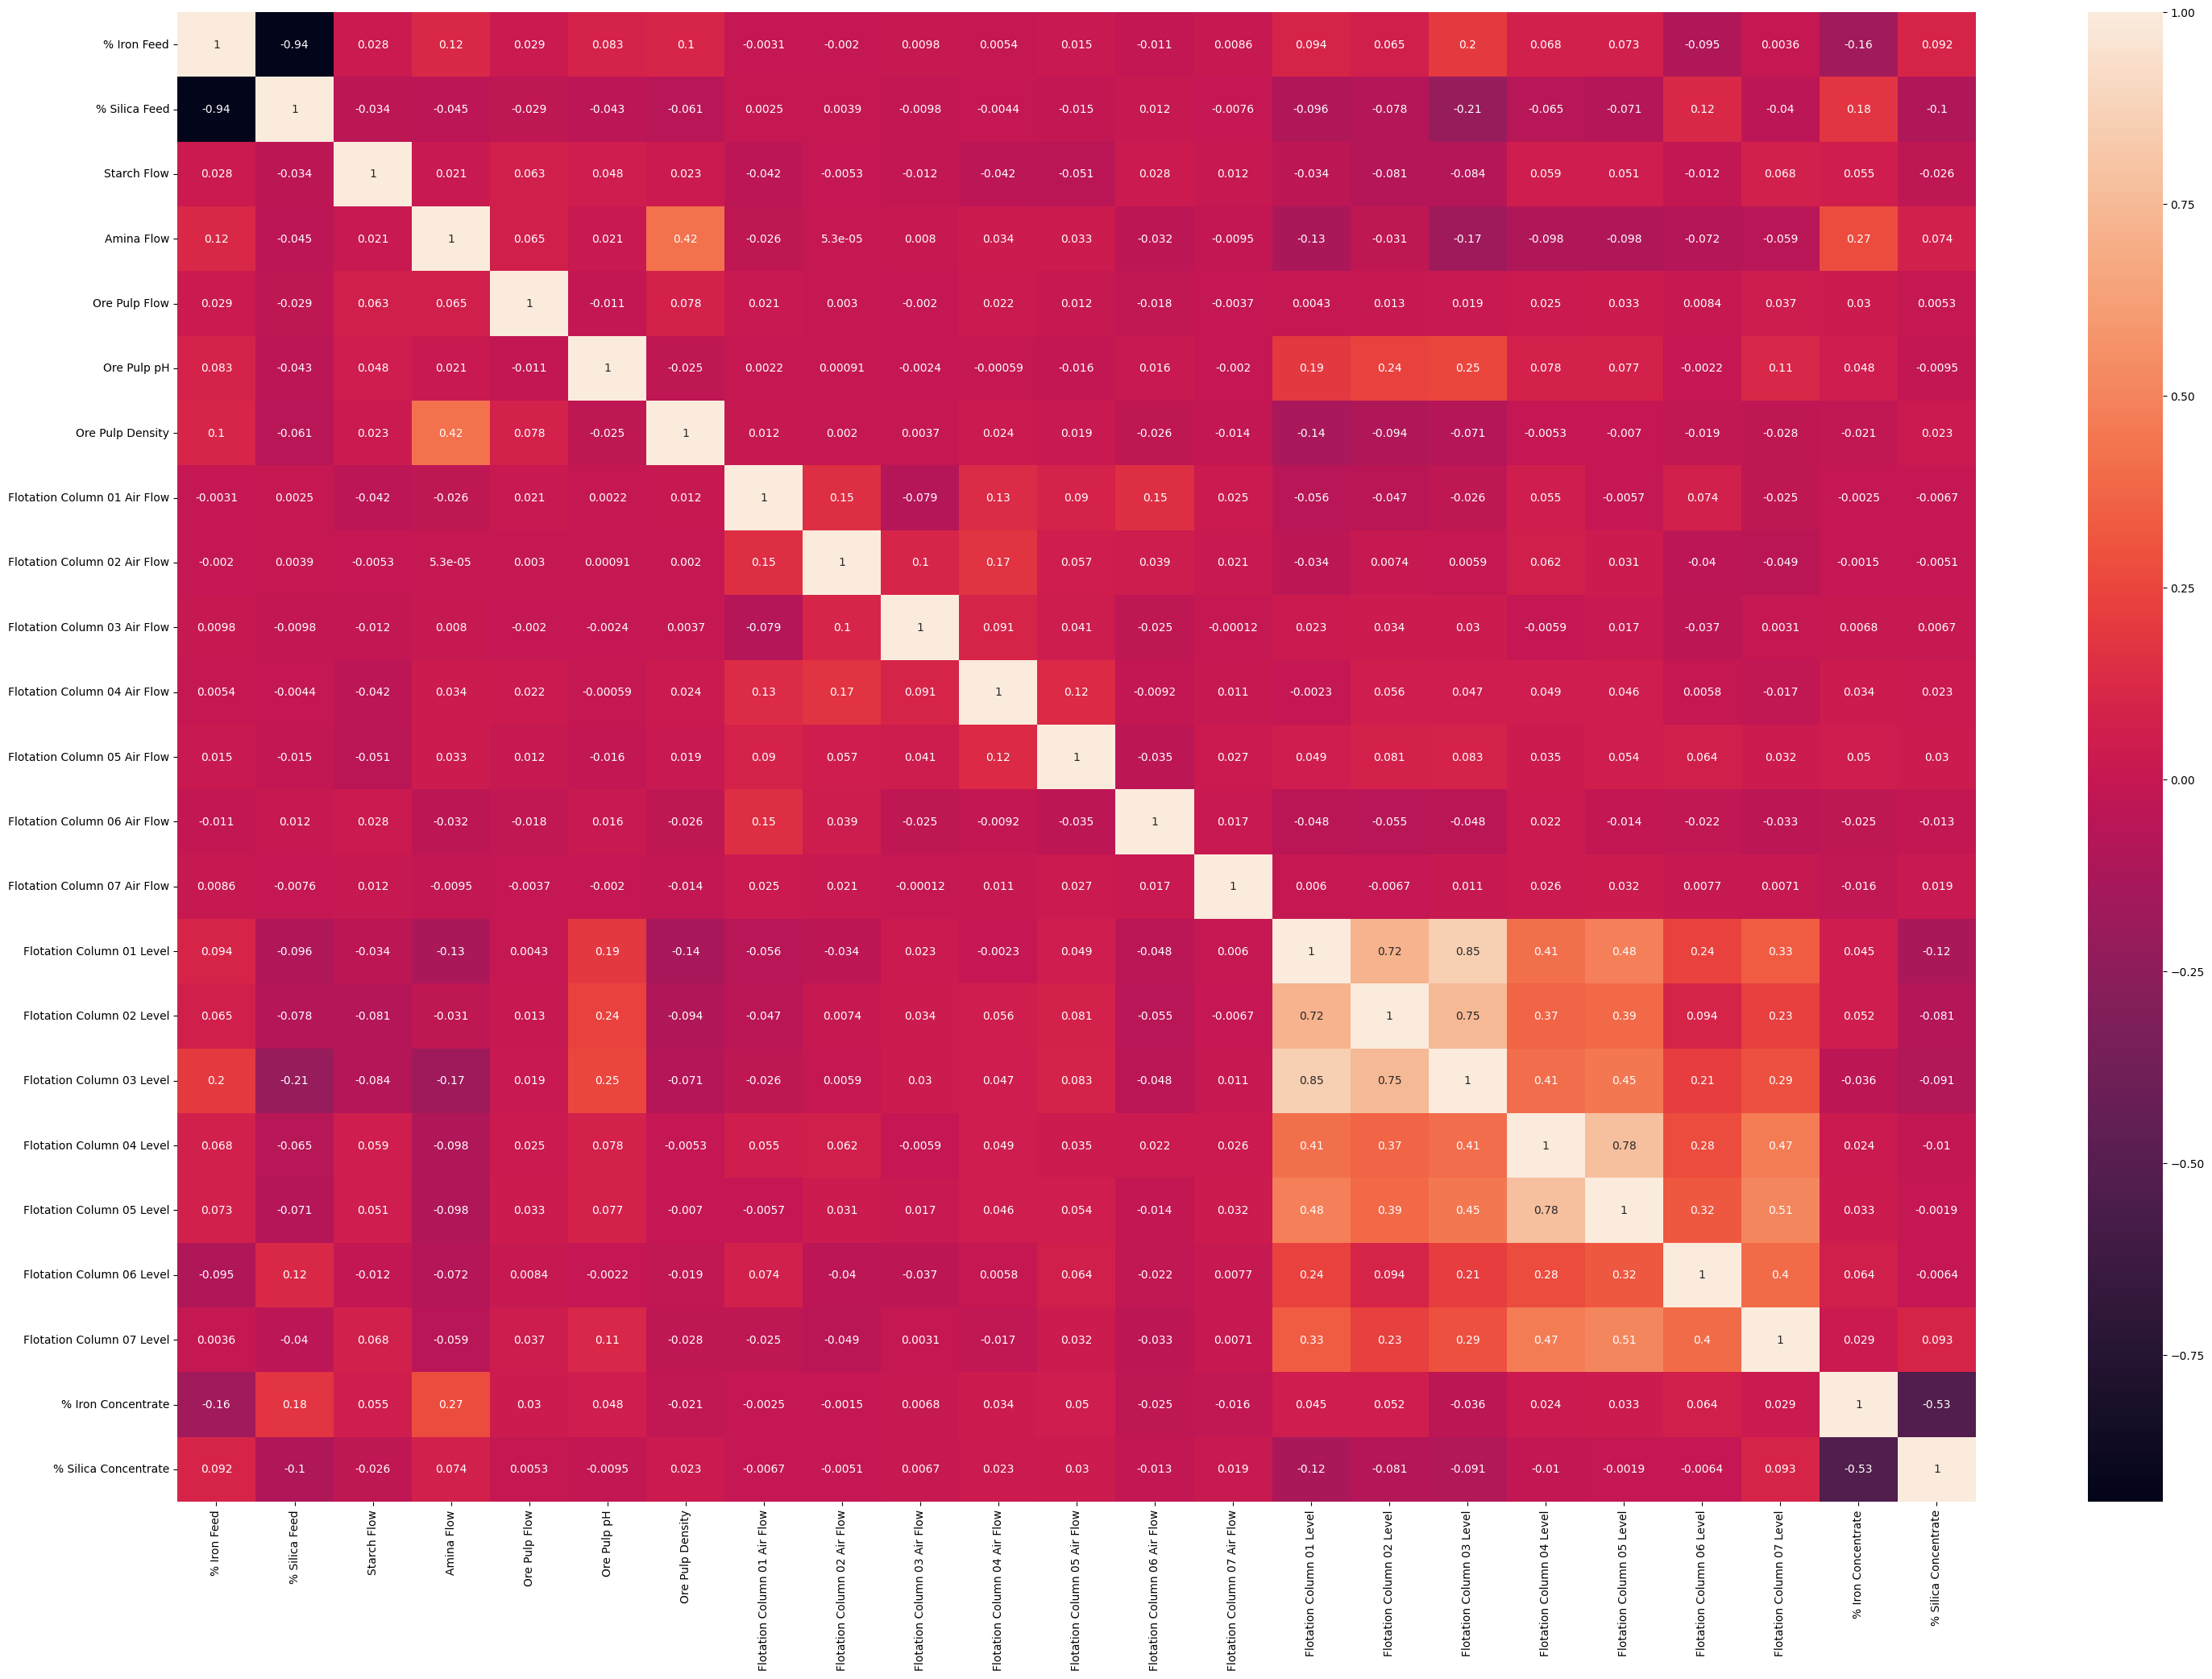

In [ ]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(36, 24))
sns.heatmap(df_corr, annot=True)

In [ ]:
df_corr[input_columns][df_corr[input_columns] >= 0.8]

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 05 Air Flow,Flotation Column 01 Level
% Iron Feed,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
% Silica Feed,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Starch Flow,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
Amina Flow,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
Ore Pulp Flow,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
Ore Pulp pH,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
Ore Pulp Density,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Flotation Column 01 Air Flow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flotation Column 02 Air Flow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flotation Column 03 Air Flow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [ ]:
df[input_columns + output_columns].describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 05 Air Flow,Flotation Column 01 Level,% Iron Concentrate,% Silica Concentrate
count,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000,23093.000000
mean,52.813491,18.631023,3535.301527,491.370329,400.151676,10.088301,1.701187,300.032099,530.165503,65.657589,1.489598
std,2.884505,4.782203,830.287376,58.840351,4.298747,0.240789,0.033935,2.226856,59.497299,0.675312,0.452804
min,46.190000,8.100000,998.783769,268.374500,387.322000,9.404690,1.583560,293.117000,303.851500,63.590000,0.960000
25%,50.800000,15.740000,3027.960000,446.637000,397.220000,9.937360,1.685260,298.349000,495.332000,65.240000,1.180000
50%,53.630000,16.860000,3533.810000,490.734000,400.267000,10.087200,1.707040,299.927000,509.033000,65.710000,1.370000
75%,55.210000,21.930000,4107.790000,534.668000,402.888000,10.253800,1.724780,301.690000,585.481000,66.200000,1.640000
max,59.380000,30.370000,5948.410000,711.994000,412.690061,10.766200,1.783450,306.351000,774.598220,66.800000,3.328504


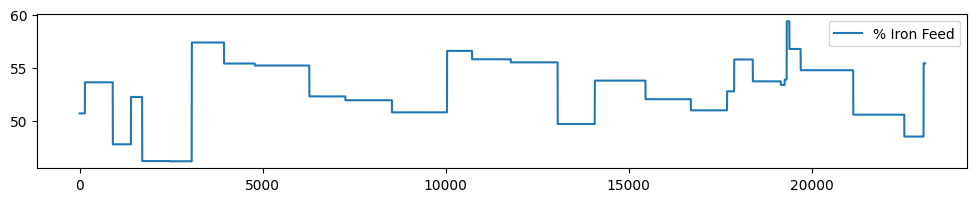

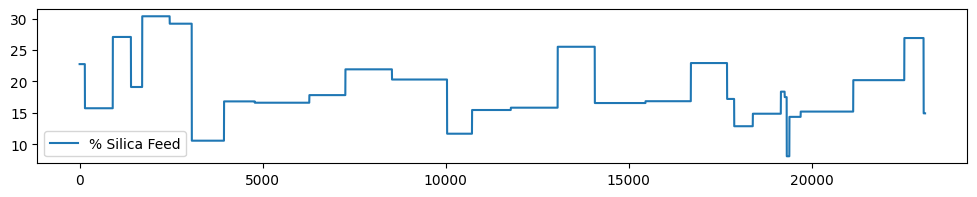

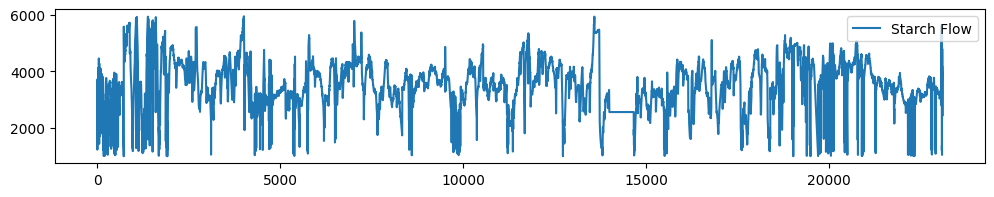

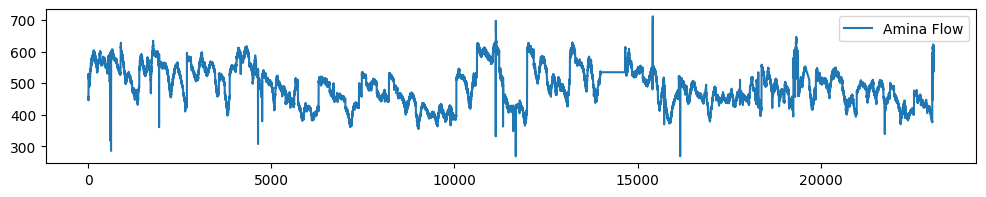

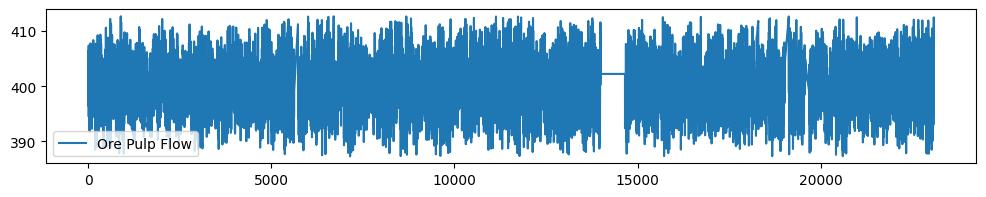

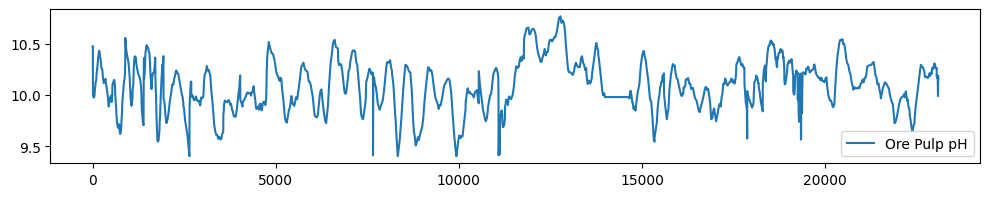

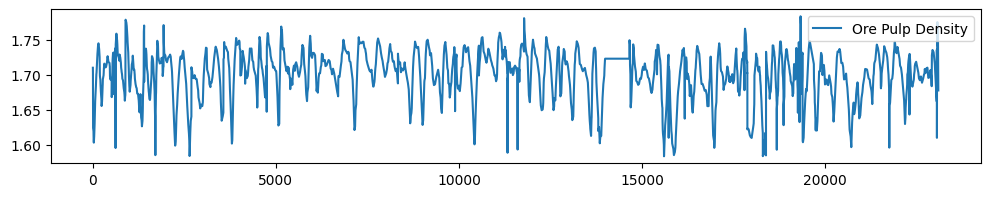

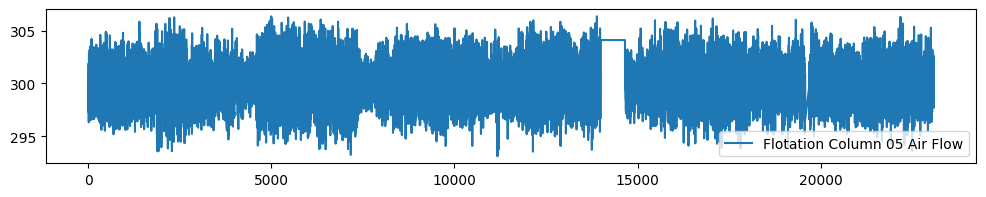

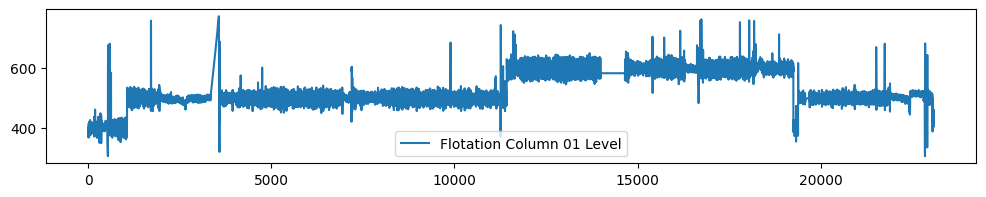

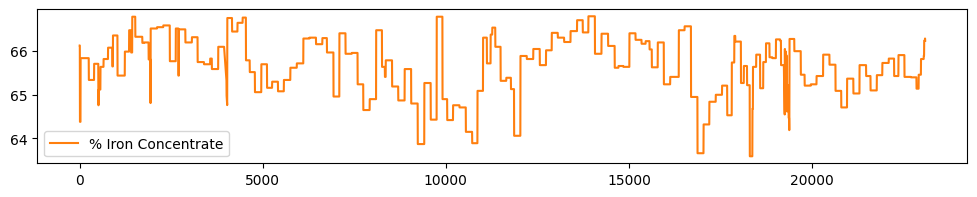

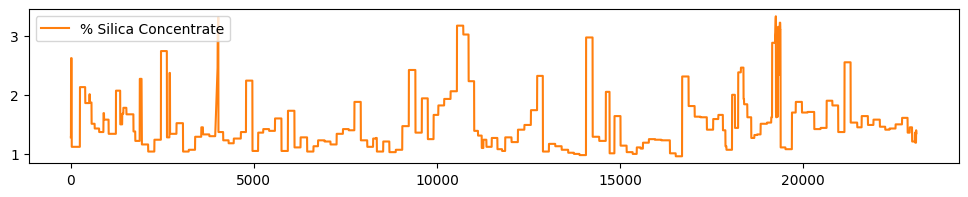

In [ ]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [ ]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [ ]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**3,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**7
}

In [ ]:
repeater = Repeater(**config).to(device)
print(repeater)

Repeater(
  (lstm): LSTM(11, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)


#### Train

In [ ]:
%%time
repeater.fit(train_dataloader, val_dataloader)

Epoch 1/128
360/360 [====================================================================================================] 100%
0.0016s 0.0016s/step - train_loss: 0.13831984 - val_loss: 0.03002640 

Epoch 2/128
360/360 [====================================================================================================] 100%
0.0030s 0.0015s/step - train_loss: 0.07387377 - val_loss: 0.02161310 

Epoch 3/128
360/360 [====================================================================================================] 100%
0.0044s 0.0015s/step - train_loss: 0.05090172 - val_loss: 0.01764599 

Epoch 4/128
360/360 [====================================================================================================] 100%
0.0058s 0.0015s/step - train_loss: 0.03914126 - val_loss: 0.01534410 

Epoch 5/128
360/360 [====================================================================================================] 100%
0.0072s 0.0014s/step - train_loss: 0.03196681 - val_loss: 0.01367266 

Epoch

In [ ]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

model_path = "./models/{}.pt".format(uuid.uuid4())
torch.jit.script(repeater).save(model_path)

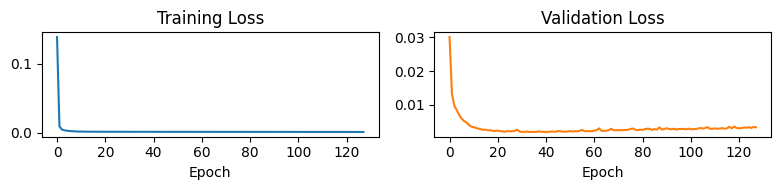

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [ ]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

Repeater(
  (lstm): LSTM(11, 8, num_layers=2, batch_first=True)
  (linear): Linear(in_features=8, out_features=2, bias=True)
  (loss_fn): MSELoss()
)

In [ ]:
# y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test_scaled = repeater.test(generator.x_test)
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

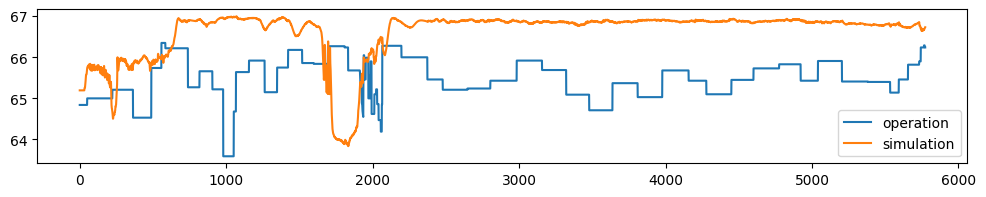

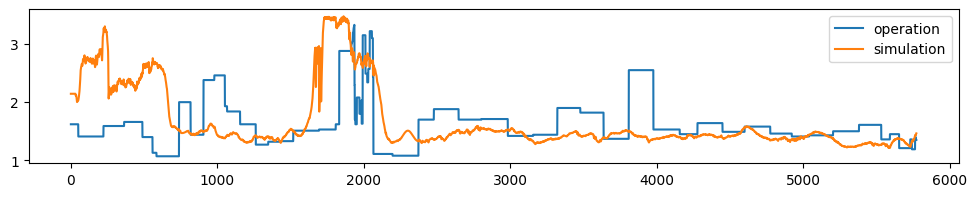

In [ ]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()

#### Evaluate

In [ ]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

{'explained_variance_score': -1.8578227702440357, 'mean_absolute_error': 1.2663240040517763, 'mean_squared_error': 1.8958558739782487, 'root_mean_squared_error': np.float64(1.3769008221285397), 'median_absolute_error': 1.3334341430664054, 'mean_absolute_percentage_error': 0.019375895504830567, 'd2_absolute_error_score': -2.4373232705991916, 'd2_pinball_score': -2.4373232705991916, 'r2_score': -7.3462375208780095}
{'explained_variance_score': -1.4411381082041892, 'mean_absolute_error': 0.41203293436464744, 'mean_squared_error': 0.3629129474024037, 'root_mean_squared_error': np.float64(0.6024225654824059), 'median_absolute_error': 0.23933146715164189, 'mean_absolute_percentage_error': 0.2609768646080972, 'd2_absolute_error_score': -0.6492002132681778, 'd2_pinball_score': -0.6492002132681778, 'r2_score': -1.4614237557144607}


In [ ]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

{'explained_variance_score': -1.6494804392242253,
 'mean_absolute_error': 0.8391784692082239,
 'mean_squared_error': 1.1293844106903248,
 'root_mean_squared_error': np.float64(1.0627249929734055),
 'median_absolute_error': 0.7863828051090236,
 'mean_absolute_percentage_error': 0.14017638005646355,
 'd2_absolute_error_score': -1.543261741933819,
 'd2_pinball_score': -1.543261741933819,
 'r2_score': -4.403830638296492}

In [ ]:
while True:
    time.sleep(1)
    pass

KeyboardInterrupt: 

### MVV Flotation

#### Data

In [ ]:
sampling_period = "1min"
# sampling_period = "2h"
interpolation_method = "linear"

df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df1.index = pd.to_datetime(df1.index)
df1.index.name = "date_time"
df1 = df1.resample("2h").interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df1.index = pd.to_datetime(pd.date_range(start=df1.index[0], end=df1.index[-1], freq=sampling_period).strftime("%Y-%m-%d %H:%M:%S.%f"))
# df1.interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df1.fillna(method='ffill', axis=0, inplace=True)


df2 = pd.read_csv('./datasets/mvv/mvv_lab_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df2.index = pd.to_datetime(df2.index)
df2.index.name = "date_time"
# df2 = df2.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df2.index = pd.to_datetime(pd.date_range(start=df2.index[0], end=df2.index[-1], freq=sampling_period).strftime("%Y-%m-%d %H:%M:%S.%f"))
# df2.interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df2.fillna(method='ffill', axis=0, inplace=True)

df3 = pd.read_csv('./datasets/mvv/mvv_courier_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df3.index = pd.to_datetime(df3.index)
df3.index.name = "date_time"
# df3 = df3.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df3.index = pd.to_datetime(pd.date_range(start=df3.index[0], periods=df3.shape[0], freq=sampling_period).strftime("%Y-%m-%d %H:%M:%S.%f"))
# df3.interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df3.fillna(method='ffill', axis=0, inplace=True)

df = pd.concat([df1, df2, df3], axis = 1)
df.sort_index(ascending=True, inplace=True)
df = df.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)
# df.interpolate(method=interpolation_method, limit_direction="both", axis=0, inplace=True)

df = df.iloc[:12500, :]
# df = df.iloc[:6000, :]
# df = df.iloc[:250, :]

In [ ]:
df31 = df3.iloc[:250, :]
df32 = df3.iloc[:250, :]

Q1 = df32.quantile(0.11, interpolation="linear")
Q3 = df32.quantile(0.89, interpolation="linear")
IQR = Q3 - Q1
df32 = df32[~((df32 < (Q1 - 1.5 * IQR)) | (df32 > (Q3 + 1.5 * IQR))).any(axis=1)]

sns.set(font_scale=1)
plt.figure(figsize=(12, 2))
df31["Rejeito Final Teor de Cu (%)"].plot()
df32["Rejeito Final Teor de Cu (%)"].plot()

In [ ]:
df["Percentual de sólidos do overflow dos ciclones (%)"].plot()
df["Alimentação da Flotação Percentual de Sólidos (%)"].plot()

In [ ]:
df1 = pd.read_csv('./datasets/mvv/mvv_rougher_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df2 = pd.read_csv('./datasets/mvv/mvv_lab_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')
df3 = pd.read_csv('./datasets/mvv/mvv_courier_dataset.csv', sep=";", decimal=',', parse_dates=["Data Hora"], infer_datetime_format=True).set_index('Data Hora')


df1.shape, df2.shape, df3.shape
df1.describe().T
# df3.index.values[0], df3.index.values[-1]

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
columns = [
    'Taxa de Alimentação da Moagem Massa Úmida (t/h)',
    # 'Taxa de Alimentação da Moagem Massa Seca (t/h)',
    'pH Rougher FC-006',
    # 'pH Rougher FC-006 - Set Point',
    'pH Rougher CD',
    # 'pH Rougher CD - Set Point',
    'Vazão de Ar Rougher CD (N.m³/h)',
    # 'Vazão de Ar Rougher CD - Set Point (N.m³/h)',
    'Jg Rougher CD (cm/s)',
    'Vazão de Ar Rougher FC-001 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-001 - Set Point (N.m³/h)',
    'Jg Rougher FC-001 (cm/s)',
    'Vazão de Ar Rougher FC-002 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-002 - Set Point (N.m³/h)',
    'Jg Rougher FC-002 (cm/s)',
    'Vazão de Ar Rougher FC-003 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-003 - Set Point (N.m³/h)',
    'Jg Rougher FC-003 (cm/s)',
    'Vazão de Ar Rougher FC-004 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-004 - Set Point (N.m³/h)',
    'Jg Rougher FC-004 (cm/s)',
    'Vazão de Ar Rougher FC-005 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-005 - Set Point (N.m³/h)',
    'Jg Rougher FC-005 (cm/s)',
    'Vazão de Ar Rougher FC-006 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-006 - Set Point (N.m³/h)',
    'Jg Rougher FC-006 (cm/s)',
    'Camada de Espuma Rougher CD (mm)',
    # 'Camada de Espuma Rougher CD - Set Point (mm)',
    'Camada de Espuma Rougher FC-001 (mm)',
    # 'Camada de Espuma Rougher FC-001 - Set Point (mm)',
    'Camada de Espuma Rougher FC-002 (mm)',
    # 'Camada de Espuma Rougher FC-002 - Set Point (mm)',
    'Camada de Espuma Rougher FC-003/FC-004 (mm)',
    # 'Camada de Espuma Rougher FC-003/FC-004 - Set Point (mm)',
    'Camada de Espuma Rougher FC-005/FC-006 (mm)',
    # 'Camada de Espuma Rougher FC-005/FC-006 - Set Point (mm)',
    # 'Sump Operando? (reservatório de contenção dos transbordos para recircular na planta)',
    'Vazão Cal Rougher CD (L/h)',
    # 'Vazão Cal Rougher CD - Set Point (L/h)',
    'Massa Dosada Cal Rougher CD (g/t)',
    # 'Massa Dosada Cal Rougher CD - Set Point (g/t)',
    'Vazão Coletor 1 Rougher FC-002 (L/h)',
    # 'Vazão Coletor 1 Rougher FC-002 - Set Point (L/h)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t Cu)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t Cu)',
    # 'Percentual de sólidos do overflow dos ciclones (%)',
    'Granulometria do overflow dos ciclones (μm)',
    # 'Alimentação da Flotação Percentual de Sólidos (%)',
    'Alimentação da Flotação Teor de Cu (%)',
    'Alimentação da Flotação Teor de Fe (%)',
    'Alimentação da Flotação Teor de Mg (%)',
    'Alimentação da Flotação Teor de Ni (%)',
    'Alimentação da Flotação Teor de SiO2 (%)',
    # 'Rejeito Rougher Percentual de Sólidos (%)',
    'Rejeito Rougher Teor de Cu (%)',
    'Rejeito Rougher Teor de Fe (%)',
    'Rejeito Rougher Teor de Mg (%)',
    'Rejeito Rougher Teor de Ni (%)',
    'Rejeito Rougher Teor de SiO2 (%)',
    # 'Concentrado Rougher CD Percentual de Sólidos (%)',
    'Concentrado Rougher CD Teor de Cu (%)',
    'Concentrado Rougher CD Teor de Fe (%)',
    'Concentrado Rougher CD Teor de Mg (%)',
    'Concentrado Rougher CD Teor de Ni (%)',
    'Concentrado Rougher CD Teor de SiO2 (%)',
    # 'Concentrado Rougher FC-001 Percentual de Sólidos (%)',
    'Concentrado Rougher FC-001 Teor de Cu (%)',
    'Concentrado Rougher FC-001 Teor de Fe (%)',
    'Concentrado Rougher FC-001 Teor de Mg (%)',
    'Concentrado Rougher FC-001 Teor de Ni (%)',
    'Concentrado Rougher FC-001 Teor de SiO2 (%)',
    # 'Concentrado Cleaner I Teor de Cu (%)',
    # 'Concentrado Cleaner II Teor de Cu (%)',
    'Concentrado Final Teor de Cu (%)',
    # 'Concentrado Rougher Teor de Cu (%)',
    # 'Concentrado Cleaner Scavanger Teor de Cu (%)',
    # 'Alimentação Flotração Teor de Cu (%)',
    # 'Rejeito Cleaner I Teor de Cu (%)',
    'Rejeito Final Teor de Cu (%)',
    # 'Rejeito Rougher Teor de Cu (%)',
    # 'Rejeito Cleaner Scavanger Teor de Cu (%)'
 ]
columns = [
    'Taxa de Alimentação da Moagem Massa Úmida (t/h)',
    # 'Taxa de Alimentação da Moagem Massa Seca (t/h)',
    'pH Rougher FC-006',
    # 'pH Rougher FC-006 - Set Point',
    'pH Rougher CD',
    # 'pH Rougher CD - Set Point',
    'Vazão de Ar Rougher CD (N.m³/h)',
    # 'Vazão de Ar Rougher CD - Set Point (N.m³/h)',
    'Jg Rougher CD (cm/s)',
    'Vazão de Ar Rougher FC-001 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-001 - Set Point (N.m³/h)',
    'Jg Rougher FC-001 (cm/s)',
    'Vazão de Ar Rougher FC-002 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-002 - Set Point (N.m³/h)',
    'Jg Rougher FC-002 (cm/s)',
    'Vazão de Ar Rougher FC-003 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-003 - Set Point (N.m³/h)',
    'Jg Rougher FC-003 (cm/s)',
    'Vazão de Ar Rougher FC-004 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-004 - Set Point (N.m³/h)',
    'Jg Rougher FC-004 (cm/s)',
    'Vazão de Ar Rougher FC-005 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-005 - Set Point (N.m³/h)',
    'Jg Rougher FC-005 (cm/s)',
    'Vazão de Ar Rougher FC-006 (N.m³/h)',
    # 'Vazão de Ar Rougher FC-006 - Set Point (N.m³/h)',
    'Jg Rougher FC-006 (cm/s)',
    'Camada de Espuma Rougher CD (mm)',
    # 'Camada de Espuma Rougher CD - Set Point (mm)',
    'Camada de Espuma Rougher FC-001 (mm)',
    # 'Camada de Espuma Rougher FC-001 - Set Point (mm)',
    'Camada de Espuma Rougher FC-002 (mm)',
    # 'Camada de Espuma Rougher FC-002 - Set Point (mm)',
    'Camada de Espuma Rougher FC-003/FC-004 (mm)',
    # 'Camada de Espuma Rougher FC-003/FC-004 - Set Point (mm)',
    'Camada de Espuma Rougher FC-005/FC-006 (mm)',
    # 'Camada de Espuma Rougher FC-005/FC-006 - Set Point (mm)',
    # 'Sump Operando? (reservatório de contenção dos transbordos para recircular na planta)',
    'Vazão Cal Rougher CD (L/h)',
    # 'Vazão Cal Rougher CD - Set Point (L/h)',
    'Massa Dosada Cal Rougher CD (g/t)',
    # 'Massa Dosada Cal Rougher CD - Set Point (g/t)',
    'Vazão Coletor 1 Rougher FC-002 (L/h)',
    # 'Vazão Coletor 1 Rougher FC-002 - Set Point (L/h)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t)',
    'Massa Dosada Coletor 1 Rougher FC-002 (g/t Cu)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 - Set Point (g/t Cu)',
    'Percentual de sólidos do overflow dos ciclones (%)',
    'Granulometria do overflow dos ciclones (μm)',
    'Alimentação da Flotação Percentual de Sólidos (%)',
    'Alimentação da Flotação Teor de Cu (%)',
    'Alimentação da Flotação Teor de Fe (%)',
    'Alimentação da Flotação Teor de Mg (%)',
    'Alimentação da Flotação Teor de Ni (%)',
    'Alimentação da Flotação Teor de SiO2 (%)',
    # 'Rejeito Rougher Percentual de Sólidos (%)',
    'Rejeito Rougher Teor de Cu (%)',
    'Rejeito Rougher Teor de Fe (%)',
    'Rejeito Rougher Teor de Mg (%)',
    'Rejeito Rougher Teor de Ni (%)',
    'Rejeito Rougher Teor de SiO2 (%)',
    # 'Concentrado Rougher CD Percentual de Sólidos (%)',
    'Concentrado Rougher CD Teor de Cu (%)',
    'Concentrado Rougher CD Teor de Fe (%)',
    'Concentrado Rougher CD Teor de Mg (%)',
    'Concentrado Rougher CD Teor de Ni (%)',
    'Concentrado Rougher CD Teor de SiO2 (%)',
    # 'Concentrado Rougher FC-001 Percentual de Sólidos (%)',
    'Concentrado Rougher FC-001 Teor de Cu (%)',
    'Concentrado Rougher FC-001 Teor de Fe (%)',
    'Concentrado Rougher FC-001 Teor de Mg (%)',
    'Concentrado Rougher FC-001 Teor de Ni (%)',
    'Concentrado Rougher FC-001 Teor de SiO2 (%)',
    # 'Concentrado Cleaner I Teor de Cu (%)',
    # 'Concentrado Cleaner II Teor de Cu (%)',
    'Concentrado Final Teor de Cu (%)',
    # 'Concentrado Rougher Teor de Cu (%)',
    # 'Concentrado Cleaner Scavanger Teor de Cu (%)',
    # 'Alimentação Flotração Teor de Cu (%)',
    # 'Rejeito Cleaner I Teor de Cu (%)',
    'Rejeito Final Teor de Cu (%)',
    # 'Rejeito Rougher Teor de Cu (%)',
    # 'Rejeito Cleaner Scavanger Teor de Cu (%)'
 ]


input_columns = [
    # 'Taxa de Alimentação da Moagem Massa Úmida (t/h)',
    # 'Taxa de Alimentação da Moagem Massa Seca (t/h)',
    'pH Rougher FC-006',
    # 'pH Rougher CD',
    # 'Vazão de Ar Rougher CD (N.m³/h)',
    # 'Jg Rougher CD (cm/s)',
    'Vazão de Ar Rougher FC-001 (N.m³/h)',
    # 'Jg Rougher FC-001 (cm/s)',
    # 'Vazão de Ar Rougher FC-002 (N.m³/h)',
    # 'Jg Rougher FC-002 (cm/s)',
    # 'Vazão de Ar Rougher FC-003 (N.m³/h)',
    # 'Jg Rougher FC-003 (cm/s)',
    # 'Vazão de Ar Rougher FC-004 (N.m³/h)',
    # 'Jg Rougher FC-004 (cm/s)',
    # 'Vazão de Ar Rougher FC-005 (N.m³/h)',
    # 'Jg Rougher FC-005 (cm/s)',
    # 'Vazão de Ar Rougher FC-006 (N.m³/h)',
    # 'Jg Rougher FC-006 (cm/s)',
    # 'Camada de Espuma Rougher CD (mm)',
    # 'Camada de Espuma Rougher FC-001 (mm)',
    # 'Camada de Espuma Rougher FC-002 (mm)',
    'Camada de Espuma Rougher FC-003/FC-004 (mm)',
    # 'Camada de Espuma Rougher FC-005/FC-006 (mm)',
    'Vazão Cal Rougher CD (L/h)',
    # 'Massa Dosada Cal Rougher CD (g/t)',
    'Vazão Coletor 1 Rougher FC-002 (L/h)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 (g/t)',
    # 'Massa Dosada Coletor 1 Rougher FC-002 (g/t Cu)',
    # 'Percentual de sólidos do overflow dos ciclones (%)',
    'Granulometria do overflow dos ciclones (μm)',
    # 'Alimentação da Flotação Percentual de Sólidos (%)',
    'Alimentação da Flotação Teor de Cu (%)',
    # 'Alimentação da Flotação Teor de Fe (%)',
    # 'Alimentação da Flotação Teor de Mg (%)',
    # 'Alimentação da Flotação Teor de Ni (%)',
    # 'Alimentação da Flotação Teor de SiO2 (%)',
]

output_columns = [
    # 'Concentrado Rougher CD Percentual de Sólidos (%)',
    # 'Concentrado Rougher CD Teor de Cu (%)',
    # 'Concentrado Rougher CD Teor de Fe (%)',
    # 'Concentrado Rougher CD Teor de Mg (%)',
    # 'Concentrado Rougher CD Teor de Ni (%)',
    # 'Concentrado Rougher CD Teor de SiO2 (%)',
    # 'Concentrado Rougher FC-001 Percentual de Sólidos (%)',
    # 'Concentrado Rougher FC-001 Teor de Cu (%)',
    # 'Concentrado Rougher FC-001 Teor de Fe (%)',
    # 'Concentrado Rougher FC-001 Teor de Mg (%)',
    # 'Concentrado Rougher FC-001 Teor de Ni (%)',
    # 'Concentrado Rougher FC-001 Teor de SiO2 (%)',
    'Concentrado Final Teor de Cu (%)',
    'Rejeito Final Teor de Cu (%)',
]

df = df[columns].astype(float)

# IQR
# Q1 = df.quantile(0.1, interpolation="midpoint")
# Q3 = df.quantile(0.9, interpolation="midpoint")
# IQR = Q3 - Q1
# df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df = df.resample(sampling_period).interpolate(method=interpolation_method, limit_direction="both", axis=0)

In [ ]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(36, 24))
sns.heatmap(df_corr, annot=True)

In [ ]:
df_corr = df[input_columns + output_columns].corr(method="pearson")

plt.figure(figsize=(36, 24))

# sns.set(font_scale=2)
sns.heatmap(df_corr, annot=True)

In [ ]:
df_corr[output_columns][np.abs(df_corr[output_columns]) >= 0.1]

In [ ]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [ ]:
df[input_columns + output_columns].describe()

In [ ]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [ ]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [ ]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**5,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0,
    "lag": lag,
    "epochs": 2**7
}

In [ ]:
repeater = Repeater(**config).to(device)
print(repeater)

#### Train

In [ ]:
%%time
repeater.fit(train_dataloader, val_dataloader)

In [ ]:
repeater.x_min_ = generator.x_scaler.min_.tolist()
repeater.x_scale_ = generator.x_scaler.scale_.tolist()
repeater.x_data_min_ = generator.x_scaler.data_min_.tolist()
repeater.x_data_max_ = generator.x_scaler.data_max_.tolist()
repeater.x_data_range_ = generator.x_scaler.data_range_.tolist()
repeater.x_n_features_in_ = generator.x_scaler.n_features_in_
repeater.x_n_samples_seen_ = generator.x_scaler.n_samples_seen_

repeater.y_min_ = generator.y_scaler.min_.tolist()
repeater.y_scale_ = generator.y_scaler.scale_.tolist()
repeater.y_data_min_ = generator.y_scaler.data_min_.tolist()
repeater.y_data_max_ = generator.y_scaler.data_max_.tolist()
repeater.y_data_range_ = generator.y_scaler.data_range_.tolist()
repeater.y_n_features_in_ = generator.y_scaler.n_features_in_
repeater.y_n_samples_seen_ = generator.y_scaler.n_samples_seen_

model_path = "./models/{}.pt".format(uuid.uuid4())
torch.jit.script(repeater).save(model_path)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [ ]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

In [ ]:
# y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test_scaled = repeater.test(generator.x_test)
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

In [ ]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()

#### Evaluate

In [ ]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

In [ ]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

In [ ]:
# recovery = concentrate / feed * (feed - reject) / (concentrate - reject)

def get_recovery(feed, concentrate, reject):
    recovery = concentrate / feed * (feed - reject) / (concentrate - reject)

    return recovery

feed = np.asarray([0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9])
concentrate = np.asarray([21.3, 21.42, 21.54, 21.66, 21.77, 21.87, 21.95, 22.03, 22.09, 22.14, 22.18, 22.22, 22.24, 22.26, 22.27])
reject = np.asarray([0.109, 0.1082, 0.1074, 0.1065, 0.1058, 0.1051, 0.1047, 0.1044, 0.1042, 0.1042, 0.1044, 0.1046, 0.105, 0.1055, 0.1061])

recovery = get_recovery(feed, concentrate, reject)

plt.figure(figsize=(12, 2))
plt.plot(feed, recovery*100)
plt.xlabel("Alimentação da Flotação Teor de Cu (%)")
plt.ylabel("Recuperação de Cu (%)")

plt.figure(figsize=(12, 2))
plt.plot(feed, concentrate)
plt.xlabel("Alimentação da Flotação Teor de Cu (%)")
plt.ylabel("Concentrado Final\n Teor de Cu (%)")

plt.figure(figsize=(12, 2))
plt.plot(feed, reject)
plt.xlabel("Alimentação da Flotação Teor de Cu (%)")
plt.ylabel("Rejeito Final\n Teor de Cu (%)")

### MVV Grinding

#### Data

In [ ]:
df = pd.read_csv('./datasets/mvv/mvv_grinding.csv', sep=";", decimal=',', parse_dates=["Timestamp"], infer_datetime_format=True).set_index('Timestamp').astype(float)
df.index = pd.to_datetime(df.index)
df.index = pd.to_datetime(pd.date_range(start=df.index[0], periods=df.shape[0], freq="5min").strftime("%Y-%m-%d %H:%M:%S.%f"))
df = df.resample("5min").interpolate(method="linear", limit_direction="both", axis=0)
df.index.name = "date_time"
# df.replace(0, np.nan, inplace=True)
df.interpolate(method="linear", limit_direction="both", axis=0)
df.fillna(method='ffill', axis=0, inplace=True)
# df = df.applymap(lambda x: 0 if x < 0 else x)

print(df.shape)

In [ ]:
# Z-score
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
tags_cols = [
    '2202_PP_001_ME1_II_FP.PV', # Corrente Bomba Alimentação Ciclonagem/Célula Rougher
    '2202_PP_002_ME1_II_FP.PV', # Corrente Bomba Alimentação Ciclonagem/Célula Rougher
    '2102-WT-001.PV', # Balança Alimentação Moagem
    '2202-DIT-0001.PV', # Densidade Alimentação Ciclonagem
    '2202-FIC-0003.PV', # Controle Adição Água Moinho
    '2202-FIT-0002.PV', # Vazão Adição Água Tanque Moinho Bolas
    '2202-JT-0001.PV', # Potência Moinho de Bolas Dividido pela Alimentação
    '2202-JT-0002.PV', # Soma Potência dos 2 Motores Moinho Bolas 
    '2202-PIC-0101.PV', # Pressão Ciclonagem
    'P80_OV_CIC_L3.PV_In' # Granulometria Alimentação Rougher
]

columns = [
    '2202_PP_001_ME1_II_FP.PV',
    # '2202_PP_002_ME1_II_FP.PV',
    '2102-WT-001.PV',
    '2202-DIT-0001.PV',
    '2202-FIC-0003.PV',
    '2202-FIT-0002.PV',
    # '2202-JT-0001.PV',
    '2202-JT-0002.PV',
    '2202-PIC-0101.PV',
    'P80_OV_CIC_L3.PV_In'
]

input_columns = [
    '2202_PP_001_ME1_II_FP.PV',
    '2102-WT-001.PV',
    # '2202-DIT-0001.PV',
    '2202-FIC-0003.PV',
    '2202-FIT-0002.PV',    
    '2202-PIC-0101.PV',
]

output_columns = [
    '2202-DIT-0001.PV',
    '2202-JT-0002.PV',
    'P80_OV_CIC_L3.PV_In',
]

df.index.names = ["date_time"]
df.columns = tags_cols
df = df[columns]

df[input_columns + output_columns].to_csv("./datasets/mvv_grinding.csv")

In [ ]:
df_corr = df.corr(method="pearson")

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True)

In [ ]:
df_corr[output_columns][df_corr[output_columns].abs() >= 0.2]

In [ ]:
input_size = len(input_columns)
output_size = len(output_columns)

x = df[input_columns].values
y = df[output_columns].values

In [ ]:
df[input_columns + output_columns].describe()

In [ ]:
for i in range(x.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(x[:, i], label=input_columns[i])
    plt.legend()
    plt.show()

for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(y[:, i], label=output_columns[i], color="tab:orange")
    plt.legend()
    plt.show()

In [ ]:
batch_size = 2**5
lag = 2**5

generator = Generator()
train_dataloader, val_dataloader = generator.generate_dataloaders(x, y, lag, batch_size)

#### Model

In [ ]:
config = {
    "input_size": input_size + output_size,
    "output_size": output_size,
    "hidden_size": 2**5,
    "num_layers": 2**1,
    "learning_rate": 1e-3,
    "dropout": 0.2,
    "lag": lag,
    "epochs": 2**6
}

In [ ]:
repeater = Repeater(**config).to(device)
print(repeater)

#### Train

In [ ]:
%%time
repeater.fit(train_dataloader, val_dataloader)

In [ ]:
model_path = './models/repeater_mvv_grinding.pt'
torch.save(repeater.state_dict(), model_path)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 2))
axs[0].plot(repeater.train_loss)
axs[0].set_title('Training Loss')
axs[1].plot(repeater.val_loss, color='tab:orange')
axs[1].set_title('Validation Loss')

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='')

fig.tight_layout()

#### Test

In [ ]:
for parameter in repeater.parameters():
  parameter.requires_grad = False
repeater.eval()

In [ ]:
y_test_scaled = repeater.test(generator.x_test, (generator.x_val, generator.y_val))
y_test = generator.y_scaler.inverse_transform(y_test_scaled)

In [ ]:
for i in range(y.shape[1]):
    plt.figure(figsize=(12, 2))
    plt.plot(generator.y_scaler.inverse_transform(generator.y_test)[:, i], label='operation')
    plt.plot(y_test[:, i], label='simulation')
    plt.legend()
    plt.show()


#### Evaluate

In [ ]:
evaluator = Evaluator()

for i in range(output_size):
    metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test)[:, i], y_test[:, i])
    print(metrics_dict)

In [ ]:
evaluator = Evaluator()
metrics_dict = evaluator.measure(generator.y_scaler.inverse_transform(generator.y_test), y_test)
metrics_dict

In [ ]:
while True:
    time.sleep(1)
    pass